# Imports  + seed

In [1]:
!pip install yfinance ta --quiet
!pip install vaderSentiment --quiet
!pip install transformers --quiet

print("Done installing.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.6 MB/s eta 0:00:00
Done installing.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import yfinance as yf
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score, roc_auc_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import kagglehub
import os
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Download latest version
path = kagglehub.dataset_download("yogeshchary/financial-news-dataset")

#understood it was relevant to make results repeatable so :
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

Using Colab cache for faster access to the 'financial-news-dataset' dataset.
TensorFlow version: 2.20.0


# Question 1

## Preparing the data  

My First Approah here is to to get the data from the package yahoo finance.
The stock I chose is 'HD' (Home Depot) as my last name is Hamra

In [3]:
# I use the yahou finance package

Stock = "HD"
start_date  = "2010-01-01"
end_date    = "2026-05-31"

# we put our financial data into a pandas data frame
df = yf.download(Stock, start=start_date, end=end_date, auto_adjust=True)
print(df.shape)
df.head(-1)


[*********************100%***********************]  1 of 1 completed

(4126, 5)


Price,Close,High,Low,Open,Volume
Ticker,HD,HD,HD,HD,HD
Date,,,,,
2010-01-04,19.297073,19.620149,19.216304,19.620149,13120900
2010-01-05,19.438425,19.512464,19.041312,19.337464,15594300
2010-01-06,19.371117,19.519193,19.317271,19.438423,8833200
2010-01-07,19.599958,19.667265,19.337458,19.424959,12058200
2010-01-08,19.505730,19.680729,19.310538,19.519191,15609800
...,...,...,...,...,...
2026-05-21,311.443970,311.652398,302.113957,304.079197,4516600
2026-05-22,310.739258,312.615171,309.141228,312.158604,2963800


In [4]:
# we see above that there is a double column at the top named 'Ticker' which ill remove for better practise later:
df.columns = df.columns.get_level_values(0)
print(df.shape)
df.head(-1)


(4126, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,19.297073,19.620149,19.216304,19.620149,13120900
2010-01-05,19.438425,19.512464,19.041312,19.337464,15594300
2010-01-06,19.371117,19.519193,19.317271,19.438423,8833200
2010-01-07,19.599958,19.667265,19.337458,19.424959,12058200
2010-01-08,19.505730,19.680729,19.310538,19.519191,15609800
...,...,...,...,...,...
2026-05-21,311.443970,311.652398,302.113957,304.079197,4516600
2026-05-22,310.739258,312.615171,309.141228,312.158604,2963800
2026-05-26,308.228088,314.431558,306.659834,312.714427,6978200


In [5]:
# reorder them :

df = df[["Open", "High", "Low", "Close", "Volume"]]
df.head(-1)

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,19.620149,19.620149,19.216304,19.297073,13120900
2010-01-05,19.337464,19.512464,19.041312,19.438425,15594300
2010-01-06,19.438423,19.519193,19.317271,19.371117,8833200
2010-01-07,19.424959,19.667265,19.337458,19.599958,12058200
2010-01-08,19.519191,19.680729,19.310538,19.505730,15609800
...,...,...,...,...,...
2026-05-21,304.079197,311.652398,302.113957,311.443970,4516600
2026-05-22,312.158604,312.615171,309.141228,310.739258,2963800
2026-05-26,312.714427,314.431558,306.659834,308.228088,6978200


In [6]:
# Now im going to add columns to the datasets that have been asked from question 1 which are :
#MOVING AVERAGES, RSI, MACD, Volatility 1 (bollinger band with) and volatility 2 (Average true Range)

data = df.copy() # Initialize a new indicators DataFrame

# Most indicators use the closing price, so i put it in a variable
closing_price = data["Close"]

# -- Moving Averagess --
# Average of the last N days. Bigger N = smoother / slower-reacting, fro now now i added 2 10 and 30 maybe it will get adjusted
data["SMA_10"] = closing_price.rolling(window=10).mean()   # short-term trend
data["SMA_20"] = closing_price.rolling(window=20).mean()   # longer-term trend

# EMA = moving average that weights recent days more (reacts faster than SMA)
data["EMA_10"] = closing_price.ewm(span=10, adjust=False).mean()

# -- RSI (momentum, 0 to 100) --
daily_change = closing_price.diff()

# Split each day's change into "gain" (up days) and "loss" (down days)
gains  = daily_change.clip(lower=0)          # keep ups, set downs to 0
losses = -daily_change.clip(upper=0)         # keep downs (flipped positive), ups to 0

# Smooth the gains and losses over 14 days (the standard RSI smoothing)
average_gain = gains.ewm(alpha=1/14, adjust=False).mean()
average_loss = losses.ewm(alpha=1/14, adjust=False).mean()

relative_strength = average_gain / average_loss
data["RSI_14"] = 100 - (100 / (1 + relative_strength))

# -- MACD (trend) --
# Compare a fast EMA (12 days) to a slow EMA (26 days)
fast_ema = closing_price.ewm(span=12, adjust=False).mean()
slow_ema = closing_price.ewm(span=26, adjust=False).mean()

data["MACD"]        = fast_ema - slow_ema                              # the MACD line
data["MACD_signal"] = data["MACD"].ewm(span=9, adjust=False).mean()  # smoothed MACD
data["MACD_diff"]   = data["MACD"] - data["MACD_signal"]   # gap between them

# --VOLATILITY 1: Bollinger Band width --
average_20  = closing_price.rolling(window=20).mean()   # middle line
spread_20   = closing_price.rolling(window=20).std()    # how spread out prices are
upper_band  = average_20 + 2 * spread_20
lower_band  = average_20 - 2 * spread_20
data["BB_width"] = (upper_band - lower_band) / average_20   # wide = volatile

# -- VOLATILITY 2: Average True Range (ATR) --
high_price      = data["High"]
low_price       = data["Low"]
yesterday_close = closing_price.shift(1)   # shift down by 1 = yesterday's value

# True Range = the biggest of these three daily distances
true_range = pd.concat([
    high_price - low_price,                  # today's high-to-low
    (high_price - yesterday_close).abs(),    # gap up from yesterday
    (low_price  - yesterday_close).abs(),    # gap down from yesterday
], axis=1).max(axis=1)

data["ATR_14"] = true_range.ewm(alpha=1/14, adjust=False).mean()

# -- remove warm-up rows --
# The first ~26 rows are blank because long indicators need history to start.
data = data.dropna().reset_index()


print(data.shape)
display(data.head(30))
display(data.tail(30))

(4107, 15)


Price,Date,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,RSI_14,MACD,MACD_signal,MACD_diff,BB_width,ATR_14
0,2010-02-01,18.852844,19.148998,18.785536,19.108612,17172100,18.891210,19.056114,18.879546,60.003928,-0.132139,-0.116565,-0.015574,0.071799,0.395117
1,2010-02-02,19.108612,19.552842,19.048035,19.539381,19640800,18.901306,19.068229,18.999516,65.730175,-0.071636,-0.107579,0.035944,0.074486,0.402952
2,2010-02-03,19.478811,19.478811,19.021119,19.162464,19437300,18.888518,19.054431,19.029143,57.916729,-0.053484,-0.096760,0.043277,0.072458,0.411189
3,2010-02-04,19.007649,19.202841,18.738419,18.798996,19813600,18.851498,19.025825,18.987298,51.552667,-0.067647,-0.090938,0.023290,0.071738,0.414991
4,2010-02-05,18.745156,18.893232,18.529772,18.832655,20229400,18.868999,18.987460,18.959181,52.077820,-0.075288,-0.087808,0.012520,0.066450,0.411310
5,2010-02-08,19.202843,19.478804,19.162457,19.243227,26005400,18.934286,18.974335,19.010826,58.051066,-0.047664,-0.079779,0.032115,0.062757,0.428085
6,2010-02-09,19.431690,19.579766,19.229767,19.431690,18057700,19.011018,18.998229,19.087347,60.485786,-0.010444,-0.065912,0.055468,0.066249,0.422507
7,2010-02-10,19.411492,19.492260,19.115339,19.283607,14481500,19.065536,19.020777,19.123030,57.654251,0.007023,-0.051325,0.058348,0.066937,0.419251
8,2010-02-11,19.323993,19.566301,19.209572,19.512455,14614200,19.176593,19.049719,19.193835,60.714962,0.038883,-0.033283,0.072167,0.070508,0.414785
9,2010-02-12,19.350921,19.519190,19.216305,19.519190,15027700,19.243228,19.073277,19.252990,60.804748,0.063939,-0.013839,0.077778,0.073781,0.406792


Price,Date,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,RSI_14,MACD,MACD_signal,MACD_diff,BB_width,ATR_14
4077,2026-04-17,340.287608,349.399257,340.287608,346.798767,4930400,334.275714,329.357607,335.906766,57.371186,-1.433049,-4.756638,3.323589,0.100721,9.068554
4078,2026-04-20,345.746688,348.555636,341.061826,348.376953,3260900,336.691595,330.858350,338.174073,58.352313,-0.275325,-3.860375,3.585050,0.107513,8.956072
4079,2026-04-21,350.302490,350.917870,340.416649,341.359589,3081000,339.187872,331.504503,338.753257,52.559688,0.075071,-3.073286,3.148357,0.110680,9.066440
4080,2026-04-22,341.389387,342.669761,335.404280,336.972504,2855800,339.519388,331.930806,338.429484,49.266932,-0.001224,-2.458874,2.457650,0.111122,8.937800
4081,2026-04-23,336.972504,338.292589,334.372014,337.627594,2712400,339.576959,332.310458,338.283686,49.772937,-0.008728,-1.968845,1.960117,0.111883,8.579427
4082,2026-04-24,335.364549,337.736740,332.188360,333.389374,3255900,339.433038,332.680682,337.393811,46.538890,-0.352599,-1.645595,1.292996,0.110334,8.362924
4083,2026-04-27,331.989874,334.868278,329.667298,329.826080,3282900,338.553632,333.209218,336.017860,43.953089,-0.902247,-1.496926,0.594679,0.103862,8.137070
4084,2026-04-28,331.960086,333.429048,324.922843,326.610199,4279300,337.198795,333.485147,334.307376,41.701132,-1.579138,-1.513368,-0.065770,0.099879,8.163437
4085,2026-04-29,323.235527,323.414179,316.674721,320.406738,4150000,335.600778,333.183409,331.779987,37.689594,-2.586333,-1.727961,-0.858372,0.104409,8.290012
4086,2026-04-30,319.840983,327.662322,319.840983,326.352142,4317900,334.771994,333.145692,330.793106,43.317467,-2.871695,-1.956708,-0.914987,0.104773,8.256535


After some research, I realized that it was important that I would use the percentage change on my values rather than the pure dollar values as my model when I'll split would be vulnerable in the training set only using values up to 2024, which wouldn't make sense, as the stock value increased a lot over the years. From 2010 to 2024, they reached 300, both of which would make the model not learn anything.

In [7]:
# Building our target column,  1= YES it went up, 0 = NO it went down

data["target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

# As said before we have an issue prices climb from 20 to 300+ dollars over the years
# we have to tackle that for our ML models after

features = pd.DataFrame(index=data.index)

features["pct_change_close"] = data["Close"].pct_change()
features["pct_change_open"] = data["Open"].pct_change()
features["range_pct"]   = (data["High"] - data["Low"]) / data["Close"]  # daily range size
features["vol_change"]  = data["Volume"].pct_change()
features["price_vs_SMA10"] = data["Close"] / data["SMA_10"] - 1 # Divide today's price by its 10-day average, then subtract 1
features["RSI_14"] = data["RSI_14"] / 100 # we don't really need to change that one  i just put it on a 0 - 1 scale
features["MACD_diff_pct"] = data["MACD_diff"] / data["Close"]
features["BB_width"] = data["BB_width"] # this one is already a percentage
features["ATR_pct"] = data["ATR_14"] / data["Close"]
features["target"] = data["target"]

# finally we drop the 1st row as it doesnt have percentage change :
features = features.dropna().reset_index(drop=True)
# we dont keep the last one as well because target ask did tomorow went up ?
features = features.iloc[:-1].reset_index(drop=True)
# Counts our target yes and no's proportion

print(features["target"].value_counts(normalize=True))
features.head()

target
1    0.529354
0    0.470646
Name: proportion, dtype: float64


,pct_change_close,pct_change_open,range_pct,vol_change,price_vs_SMA10,RSI_14,MACD_diff_pct,BB_width,ATR_pct,target
0,0.022543,0.013567,0.025835,0.143762,0.033758,0.657302,0.001840,0.074486,0.020623,0
1,-0.019290,0.019373,0.023885,-0.010361,0.014503,0.579167,0.002258,0.072458,0.021458,0
2,-0.018968,-0.024188,0.024705,0.019360,-0.002785,0.515527,0.001239,0.071738,0.022075,1
3,0.001790,-0.013810,0.019299,0.020986,-0.001926,0.520778,0.000665,0.066450,0.021840,1
4,0.021801,0.024416,0.016439,0.285525,0.016316,0.580511,0.001669,0.062757,0.022246,1


## Scaling, Window and SPlitting

It's critical here to not shuffle the data as we need it by order, so we just split it by sections.

In [8]:
# the model's features = every column EXCEPT the answer
feature_cols = [c for c in features.columns if c != "target"]

X_table = features[feature_cols].values   # the clues, as plain numbers
y_all   = features["target"].values       # the answers (1 = up, 0 = down)



# Then i decide the split points
n = len(features)                 # total number of rows we have
train_end = int(n * 0.70)         # first 70% of rows -> training
val_end   = int(n * 0.85)         # next 15% -> validation; last 15% -> test

In [9]:
# Scaling our features to have every feature on a similar footing centered at 0

scaler = StandardScaler()              # create the scaling tool
scaler.fit(X_table[:train_end])        # learn averages/spreads from TRAIN ONLY
X_scaled = scaler.transform(X_table)   # apply that scaling to EVERYTHING

In [10]:
# Now i have to build a "window" as the models we are going to use don't predict from a single day
WINDOW = 30 # will try with 20 and 60

def make_sequences(X, y, window):
    X_seq, y_seq = [], []                  # empty buckets to fill
    for i in range(window, len(X)):        # start at day 30, go to the end
        X_seq.append(X[i-window:i])        # the 30 days BEFORE day i
        y_seq.append(y[i])                 # the answer ON day i
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = make_sequences(X_scaled, y_all, WINDOW)


In [11]:
# and now we can cut points to match

# the windows are shifted by variable "WINDOW"
tr = train_end - WINDOW
va = val_end   - WINDOW

X_train, y_train = X_seq[:tr],   y_seq[:tr]
X_val,   y_val   = X_seq[tr:va], y_seq[tr:va]
X_test,  y_test  = X_seq[va:],   y_seq[va:]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (2843, 30, 9)  Val: (616, 30, 9)  Test: (616, 30, 9)


## OUR reusable function


In [12]:
# i create a function for training our models
#  I choose to use Adam because it merges momentum and adaptive per-weight step sizes into one reliable, low-tuning method the modern default for exactly these kinds of models

def train_model(model, name):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),   # HOW it adjusts itself; 1e-3 = step size
        loss="binary_crossentropy",              # HOW wrong it is (correct loss for 0/1)
        metrics=["accuracy"],                    # a human-readable score to watch
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",          # watch the error on the VALIDATION set
        patience=8,                  # if it doesn't improve for 8 rounds in a row...
        restore_best_weights=True,   # ...stop, and roll back to the best version seen
    )
    history = model.fit(
        X_train, y_train,                    # study material + answers
        validation_data=(X_val, y_val),      # a quiz it doesn't learn from, only checks
        epochs=60,                           # up to 60 full passes over the data
        batch_size=32,                       # learn in small groups of 32 clips at a time
        callbacks=[early_stop],              # use the early-stop rule above
        verbose=1,                           # print progress each round
    )
    print(f"{name}: finished")
    return history

## MODEL 1 : LSTM

In [13]:
# I place here the hyperparameters i might change
lstm_units = 64
dropout_rate = 0.3
dense_units = 32

n_steps = X_train.shape[1]    # (days per clip)
n_feat  = X_train.shape[2]    # (features per day)


lstm_model = keras.Sequential([
    layers.Input(shape=(n_steps, n_feat)),            # each clip is N days x 9 features
    layers.LSTM(lstm_units),                          # the memory layer that reads the 30 days
    layers.Dropout(dropout_rate),                     # turn off a percentage of neurons while training (anti-overfit)
    layers.Dense(dense_units, activation="relu"),     # a small "reasoning" layer
    layers.Dense(1, activation="sigmoid"),            # final answer: probability of "Up" (0 to 1)
], name="LSTM")



In [14]:
train_model(lstm_model, "LSTM")

Epoch 1/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5139 - loss: 0.6972 - val_accuracy: 0.5308 - val_loss: 0.6946
Epoch 2/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5248 - loss: 0.6927 - val_accuracy: 0.5162 - val_loss: 0.6968
Epoch 3/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5329 - loss: 0.6924 - val_accuracy: 0.5162 - val_loss: 0.6959
Epoch 4/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5336 - loss: 0.6917 - val_accuracy: 0.5260 - val_loss: 0.6964
Epoch 5/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5280 - loss: 0.6899 - val_accuracy: 0.5146 - val_loss: 0.6983
Epoch 6/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5364 - loss: 0.6887 - val_accuracy: 0.5146 - val_loss: 0.7011
Epoch 7/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5484 - loss: 0.6868 - val_accuracy: 0.5162 - val_loss: 0.7013
Epoch 8/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5501 - loss: 0.6858 - val_accuracy: 0.5114 - 

## Model 2 : GRU

In [15]:
gru_units    = 32 # units = neurons
dropout_rate = 0.2
dense_units  = 32

gru_model = keras.Sequential([
    layers.Input(shape=(n_steps, n_feat)),
    layers.GRU(gru_units),                      # <-- the only real change vs LSTM
    layers.Dropout(dropout_rate),
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="GRU")

gru_model.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,217 (20.38 KB)

 Trainable params: 5,217 (20.38 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
train_model(gru_model, "GRU")

Epoch 1/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5227 - loss: 0.6963 - val_accuracy: 0.5146 - val_loss: 0.6982
Epoch 2/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5276 - loss: 0.6917 - val_accuracy: 0.5146 - val_loss: 0.6984
Epoch 3/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5237 - loss: 0.6899 - val_accuracy: 0.5146 - val_loss: 0.6985
Epoch 4/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5410 - loss: 0.6873 - val_accuracy: 0.5211 - val_loss: 0.6984
Epoch 5/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5336 - loss: 0.6880 - val_accuracy: 0.5130 - val_loss: 0.6991
Epoch 6/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5434 - loss: 0.6864 - val_accuracy: 0.5114 - val_loss: 0.6994
Epoch 7/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5579 - loss: 0.6856 - val_accuracy: 0.4984 - val_loss: 0.7014
Epoch 8/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5519 - loss: 0.6835 - val_accuracy: 0.4854 - v

## Model 3 : CNN

In [17]:
# MODEL 3 : 1D CNN for time series
cnn_filters  = 32
dropout_rate = 0.3
dense_units  = 32

cnn_model = keras.Sequential([
    layers.Input(shape=(n_steps, n_feat)),
    layers.Conv1D(cnn_filters, kernel_size=3, activation="relu", padding="causal"),  # scan 3 days at a time
    layers.Conv1D(cnn_filters, kernel_size=3, activation="relu", padding="causal"),
    layers.GlobalMaxPooling1D(),                     # keep the strongest pattern found
    layers.Dropout(dropout_rate),
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(1, activation="sigmoid"),           # still Up/Down probability
], name="CNN")

cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,089 (19.88 KB)

 Trainable params: 5,089 (19.88 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
train_model(cnn_model, "CNN")

Epoch 1/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.5227 - loss: 0.7036 - val_accuracy: 0.5081 - val_loss: 0.6912
Epoch 2/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5199 - loss: 0.6970 - val_accuracy: 0.5617 - val_loss: 0.6899
Epoch 3/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5294 - loss: 0.6916 - val_accuracy: 0.5390 - val_loss: 0.6891
Epoch 4/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5297 - loss: 0.6919 - val_accuracy: 0.5422 - val_loss: 0.6899
Epoch 5/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5385 - loss: 0.6915 - val_accuracy: 0.5406 - val_loss: 0.6898
Epoch 6/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5410 - loss: 0.6910 - val_accuracy: 0.5049 - val_loss: 0.6914
Epoch 7/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5448 - loss: 0.6880 - val_accuracy: 0.5130 - val_loss: 0.6925
Epoch 8/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5420 - loss: 0.6894 - val_accuracy: 0.5195 - val_loss

## Analysis

**What I did :**
I picked the HD (Home Depot) stock and pulled its daily data from Yahoo Finance. I kept the basic values (Open, High, Low, Close, Volume) and added the indicators asked in the question : moving averages, RSI, MACD and two volatility measures. Because the price grows a lot over the years (from about 20 to 400), I turned most features into percentages and ratios so they stay comparable across time. Then I built the target : 1 if the next day closes higher, 0 if it closes lower. I used the last 30 days as input for each prediction, split the data by time (70% train, 15% validation, 15% test), and scaled it using the training part only to avoid leakage.

**LSTM**
The LSTM reads the 30 days one by one and keeps a small memory while going through them. I trained it and tried a few settings (different units, dropout and window size). The training accuracy slowly went up but the validation accuracy stayed around 0.52, and the validation loss started going up : a sign of overfitting. Smaller models worked better than bigger ones.

**GRU**
The GRU is a simpler version of the LSTM with fewer gates, so it trains a bit faster. I tested several sizes again. The result was basically the same as the LSTM : validation accuracy around 0.53, and the big version (128 units) actually did worse because it overfit more.

**CNN**
The CNN works differently : instead of memory, it slides small filters across the 30 days to catch short local patterns. It trained much faster than the LSTM and GRU. The accuracy landed in the same place : around 0.53, and again the smallest version was the most stable while the largest one overfit.

**Final conclusion**
All three models gave almost the same result : around 0.52 to 0.53 accuracy, which is very close to a coin flip (50%). Changing the size, dropout, window or even the type of model did not really help, and the differences were inside the random noise. The training accuracy could go up while the validation stayed flat, which told me the models can fit the data but there is no real signal to generalize. So my conclusion is that the limit comes from the problem itself, not the model : predicting the daily direction of a stock is close to random, which matches the idea that markets are efficient. The point of this part was less about beating the market and more about building three working models (LSTM, GRU, CNN) and comparing them honestly without data leakage.

# Question 2

## Combining LSTM + GRU + CNN

After Looking online different options for best answering question 2 I found that there is usually 3 techniques to stack up models to get one output:
- bagging, (which is many copies of 1 model) not relevant in our case
- boosting, (models trained one after another, each fixing the last one's mistakes) I think this one would overfit too much based on our situation
- stacking: thats the one im going to choose as its feeds all the predictions in a meta_model that learns to combine them.

In [19]:
#combining LSTM + GRU + CNN (stacking)

# Each trained base model gives a probability of "Up" on val and on test
def get_probs(model):
    return model.predict(X_val, verbose=0).ravel(), model.predict(X_test, verbose=0).ravel()

lstm_val, lstm_test = get_probs(lstm_model)
gru_val,  gru_test  = get_probs(gru_model)
cnn_val,  cnn_test  = get_probs(cnn_model)

# Put the 3 probabilities side by side -> a 3-column table (one column per model)
stack_val  = np.column_stack([lstm_val,  gru_val,  cnn_val])    # shape (616, 3)
stack_test = np.column_stack([lstm_test, gru_test, cnn_test])

print("Stacked input shape:", stack_val.shape)

Stacked input shape: (616, 3)


For the combination of the models, I just went for a simple sigmoid output, as there are not many patterns to learn on. All the previous base models were converging around 0.54-0.55, which is basically random, so that was my approach.

In [20]:
# A SIMPLE meta-model: just 3 inputs -> 1 sigmoid output (a logistic regression)
# Kept simple on purpose: only 616 rows to learn from, so no hidden layer (avoids overfitting)
meta_model = keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(1, activation="sigmoid"),     # final UP/DOWN probability
], name="Meta")

meta_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss="binary_crossentropy", metrics=["accuracy"])

# Train the meta-model on the VALIDATION predictions (base models never learned from val -> no leakage)
meta_model.fit(stack_val, y_val, epochs=50, batch_size=32, verbose=0)
print("Meta-model trained.")

Meta-model trained.


I first went with the approach of adding a dense layer, but it ended up backfiring and not adding any benefits. I chose simplicity and just kept a very simple model with just a sigmoid activation. That's it.

In [21]:
# --- Stacked model prediction on the untouched TEST set ---
meta_prob = meta_model.predict(stack_test, verbose=0).ravel()
meta_pred = (meta_prob > 0.5).astype(int)

# --- Simple average (soft voting) baseline, for comparison ---
avg_prob = stack_test.mean(axis=1)            # average the 3 columns per row
avg_pred = (avg_prob > 0.5).astype(int)

def scores(y_true, pred, prob):
    return {"accuracy": round(accuracy_score(y_true, pred), 3),
            "f1":       round(f1_score(y_true, pred, zero_division=0), 3),
            "roc_auc":  round(roc_auc_score(y_true, prob), 3)}

import pandas as pd
comparison = pd.DataFrame({
    "LSTM":            scores(y_test, (lstm_test > 0.5).astype(int), lstm_test),
    "GRU":             scores(y_test, (gru_test  > 0.5).astype(int), gru_test),
    "CNN":             scores(y_test, (cnn_test  > 0.5).astype(int), cnn_test),
    "Average (vote)":  scores(y_test, avg_pred,  avg_prob),
    "Stacked (meta)":  scores(y_test, meta_pred, meta_prob),
}).T

baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"Naive baseline (always majority class): {baseline:.3f}\n")
comparison

Naive baseline (always majority class): 0.515



,accuracy,f1,roc_auc
LSTM,0.481,0.645,0.509
GRU,0.505,0.651,0.545
CNN,0.487,0.649,0.483
Average (vote),0.485,0.654,0.519
Stacked (meta),0.485,0.654,0.447



The individual models reached around 0.53 on the validation set, but only about 0.48 on the test set, and the stacked ensemble came out at roughly the same 0.48. I don't think this drop comes from the stacking itself, since the individual models dropped in the same way. My guess is that it mostly comes from the fact that validation and test cover different time periods, so the accuracy can move around a bit between them. Since the results all sit close to 0.50, it seems like the models are landing near random guessing, which would explain why the number shifts a little above or below 0.50 depending on the period. The validation score might also have looked slightly better because early stopping keeps the best validation epoch, so it can be a bit optimistic compared to the test set. Overall, the fact that the score didn't really hold from validation to test makes me think the models aren't capturing a strong, stable signal, which would line up with the idea that predicting daily stock direction is close to random. I'm not certain this is the full explanation, but it seems like the most likely one based on what I saw as of now.



# Question 3

My first approach here was to look at different possibilities for getting a clean, usable dataset. After not finding what I wanted online, I managed to go on MarketShare and, by inspecting the page and seeing the HTML code, I was able to get the headlines of articles from 2020 to 2026. Which completed the dataset I found on Kaggle that was going from 2010 to 2020 on stocks. With that, I was able to proceed forward and started building my models.

## Loading and Cleaning Datasets

In [22]:
# Text-cleaning function reused on every headline later
def clean_text(text):
    text = text.lower()                       # "Home"/"home" -> same word
    text = re.sub(r"http\S+", "", text)       # remove web links
    text = re.sub(r"[^a-z\s]", " ", text)     # keep letters only (drop digits/punctuation)
    text = re.sub(r"\s+", " ", text).strip()  # squeeze extra spaces
    return text

# My own scraped MarketWatch headlines (HD only, 2020–2026)
url = "https://raw.githubusercontent.com/simonhamra/Predicting-if-a-stock-goes-UP-or-DOWN-/refs/heads/main/data/home_depot_only_dataset.csv"
mw = pd.read_csv(url)
mw["date"] = pd.to_datetime(mw["date"])
mw = mw[["date", "headline"]].dropna()
mw["source"] = "marketwatch"          # tag the origin

print("MarketWatch HD headlines:", len(mw))
print("Range:", mw["date"].min().date(), "->", mw["date"].max().date())
mw.head()

MarketWatch HD headlines: 1065
Range: 2020-01-27 -> 2026-06-20


,date,headline,source
0,2020-01-27,Home Depot stock price target raised to $255 f...,marketwatch
1,2020-02-11,"Home Depot to hire 80,000 workers for spring, ...",marketwatch
2,2020-02-11,"Home Depot to hire 80,000 employees for spring...",marketwatch
3,2020-02-14,Home Depot stock price target raised to $265 f...,marketwatch
4,2020-02-23,"Home Depot, Salesforce, Macy’s, and Other Stoc...",marketwatch


To make this possible, on the MarketShare website there was macro news and micro news, and I decided not only to use the news where Home Depot was clearly indicated, as it would be more accurate, in my opinion, when making the sentiment analysis.

Now I download the Kaggle dataset and load HD headlines from its cleaned analyst-ratings file, keeping only rows that actually mention 'Home Depot' (the ticker tag alone is noisy).

In [23]:
#Download Kaggle "Daily Financial News for 6000+ Stocks"
path = kagglehub.dataset_download("miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests")

# Cleaned analyst-ratings file; its 'title' column holds the headline
proc = pd.read_csv(os.path.join(path, "analyst_ratings_processed.csv"),
                   usecols=["title", "date", "stock"])

# Two-step filter: tagged HD AND headline really says "home depot"
k1 = proc[(proc["stock"] == "HD") &
          (proc["title"].str.contains("home depot", case=False, na=False))].copy()

k1 = k1.rename(columns={"title": "headline"})                                  # standardize column name
k1["date"] = pd.to_datetime(k1["date"], errors="coerce", utc=True).dt.tz_localize(None)
k1 = k1[["date", "headline"]].dropna()
k1["source"] = "kaggle_analyst"

print("Kaggle analyst HD headlines:", len(k1))
print("Range:", k1["date"].min().date(), "->", k1["date"].max().date())
k1.head()

100%|██████████| 210M/210M [00:12<00:00, 17.4MB/s]

Extracting files...


Kaggle analyst HD headlines: 1113
Range: 2009-08-17 -> 2020-06-10


,date,headline,source
595270,2020-06-10 11:33:00,"UBS Maintains Buy on Home Depot, Raises Price ...",kaggle_analyst
595273,2020-05-25 19:12:00,"The Street Deconstructs Home Depot, Lowe's Ear...",kaggle_analyst
595277,2020-05-21 12:00:00,Morgan Stanley Maintains Overweight on Home De...,kaggle_analyst
595279,2020-05-20 15:41:00,"UPDATE: Nomura Maintains Buy On Home Depot, Ra...",kaggle_analyst
595280,2020-05-20 15:19:00,UPDATE: Raymond James Maintains Outperform On ...,kaggle_analyst


I add more clean HD headlines from the partner-headlines file (a different set of articles), using the same 'Home Depot' filter.

In [24]:
# Second Kaggle file: partner (syndicated) headlines — a different article set ===
partner = pd.read_csv(os.path.join(path, "raw_partner_headlines.csv"),
                      usecols=["headline", "date", "stock"])

# Same two-step filter: tagged HD AND mentions "home depot"
k2 = partner[(partner["stock"] == "HD") &
             (partner["headline"].str.contains("home depot", case=False, na=False))].copy()

k2["date"] = pd.to_datetime(k2["date"], errors="coerce", utc=True).dt.tz_localize(None)
k2 = k2[["date", "headline"]].dropna()
k2["source"] = "kaggle_partner"

print("Kaggle partner HD headlines:", len(k2))
print("Range:", k2["date"].min().date(), "->", k2["date"].max().date())
k2.head()

Kaggle partner HD headlines: 481
Range: 2018-05-01 -> 2020-05-27


,date,headline,source
762146,2020-05-27,"Highlander Capital Management, LLC Buys The Ho...",kaggle_partner
762148,2020-05-22,Mcmillion Capital Management Inc Buys Truist F...,kaggle_partner
762149,2020-05-22,The Home Depot Inc (HD) EVP - U.S. Stores Ann ...,kaggle_partner
762152,2020-05-21,Capital Advisors Inc Buys Vanguard Short-Term ...,kaggle_partner
762156,2020-05-20,Home Depot Reports –st-Quarter Results,kaggle_partner


I combine all three clean sources into one Home Depot news dataset, remove duplicate headlines, clean the text, and summarize what I ended up with

In [25]:
## Combine all three clean sources ===
news = pd.concat([k1, k2, mw], ignore_index=True)

# Normalize dates to day-level (drop time) so dedup/merging is consistent
news["date"] = pd.to_datetime(news["date"]).dt.normalize()

# Remove exact duplicate headlines on the same day (overlap between sources)
before = len(news)
news = news.drop_duplicates(subset=["date", "headline"]).sort_values("date").reset_index(drop=True)
print("Removed", before - len(news), "duplicates")


# I remove the 2009 datapoints because we only used financial dat from 2010-01-01
news = news[news["date"] >= "2010-01-01"].reset_index(drop=True)


# Clean the text for modeling
news["clean"] = news["headline"].apply(clean_text)

# Final summary
print("\nFINAL HD news dataset:", len(news), "headlines")
print("Range:", news["date"].min().date(), "->", news["date"].max().date())
print("\nBy source:\n", news["source"].value_counts())
print("\nBy year:\n", news["date"].dt.year.value_counts().sort_index())
news.head()

Removed 12 duplicates

FINAL HD news dataset: 2640 headlines
Range: 2010-01-26 -> 2026-06-20

By source:
 source
kaggle_analyst    1096
marketwatch       1065
kaggle_partner     479
Name: count, dtype: int64

By year:
 date
2010     65
2011    102
2012    124
2013    117
2014    142
2015     80
2016     84
2017    103
2018    236
2019    353
2020    347
2021    131
2022    144
2023    110
2024     64
2025     63
2026    375
Name: count, dtype: int64


,date,headline,source,clean
0,2010-01-26,"Home Depot To Cut 1,000 Jobs",kaggle_analyst,home depot to cut jobs
1,2010-02-17,Home Depot Upgraded At Oppenheimer (HD),kaggle_analyst,home depot upgraded at oppenheimer hd
2,2010-02-22,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",kaggle_analyst,home depot inc nyse hd stumbles into possible top
3,2010-02-22,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",kaggle_analyst,home depot inc nyse hd stumbles into possible ...
4,2010-02-22,Home Depot Earnings Preview (HD),kaggle_analyst,home depot earnings preview hd


Now that the dataset is settled, I will need to move on to the sentiment labeling of those news. To do that, I will use previous datasets that labeled financial news in order to train the model on it and to best label our newly made dataset for Home Depot.

In [26]:
# Financial PhraseBank: ~5k finance sentences hand-labeled positive/negative/neutral
pb_path = kagglehub.dataset_download("ankurzing/sentiment-analysis-for-financial-news")
print("Files:", os.listdir(pb_path))
# the file has no header; columns are [sentiment, text], latin-1 encoded
pb = pd.read_csv(os.path.join(pb_path, "all-data.csv"),
                 encoding="latin-1", header=None, names=["sentiment", "text"])

print("\nTotal labeled sentences:", len(pb))
print("\nLabel counts:")
print(pb["sentiment"].value_counts())
pb.head()

Using Colab cache for faster access to the 'sentiment-analysis-for-financial-news' dataset.
Files: ['all-data.csv', 'FinancialPhraseBank']

Total labeled sentences: 4846

Label counts:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


Lastly, I'm going to load a last dataset where previous financial news headlines have been labeled as positive or negative, because the problem is our current dataset has not been labeled, we need to label it to perform the sentiment analysis. I might use another approach that is rule based later on called "VADER"

In [27]:
# keep only positive / negative (drop "neutral") -> a clean binary problem
pb = pb[pb["sentiment"].isin(["positive", "negative"])].copy()

# turn labels into numbers: positive -> 1, negative -> 0
pb["label"] = (pb["sentiment"] == "positive").astype(int)

# clean the text the SAME way as our HD headlines (so the model sees consistent input)
pb["clean"] = pb["text"].apply(clean_text)

print("PhraseBank pos/neg sentences:", len(pb))
print(pb["label"].value_counts())     # check the balance
pb[["text", "clean", "sentiment", "label"]].head()

PhraseBank pos/neg sentences: 1967
label
1    1363
0     604
Name: count, dtype: int64


,text,clean,sentiment,label
2,The international electronic industry company ...,the international electronic industry company ...,negative,0
3,With the new production plant the company woul...,with the new production plant the company woul...,positive,1
4,According to the company 's updated strategy f...,according to the company s updated strategy fo...,positive,1
5,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,financing of aspocomp s growth aspocomp is agg...,positive,1
6,"For the last quarter of 2010 , Componenta 's n...",for the last quarter of componenta s net sales...,positive,1


## Sentiment Models

### LSTM

The new thing we had compared to the other models we used later is the embedding layer. Which in my understanding of things, turns every word into a vector of learnable numbers for meaning

In [28]:
# 3-way split: train to learn, val to choose the threshold, test for the final score
train_text, temp_text, y_train_pb, y_temp = train_test_split(
    pb["clean"], pb["label"], test_size=0.30, random_state=42, stratify=pb["label"])
val_text, test_text, y_val_pb, y_test_pb = train_test_split(
    temp_text, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# settings (these used to live in the old cell — moved here so it's self-contained)
VOCAB_SIZE, MAX_LEN = 10000, 30

# tokenize on TRAIN only (no leakage), transform all three
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_text)
to_seq = lambda t: pad_sequences(tokenizer.texts_to_sequences(t),
                                 maxlen=MAX_LEN, padding="post", truncating="post")
X_train_pb, X_val_pb, X_test_pb = to_seq(train_text), to_seq(val_text), to_seq(test_text)
y_train_pb, y_val_pb, y_test_pb = y_train_pb.values, y_val_pb.values, y_test_pb.values

print("Train:", X_train_pb.shape, " Val:", X_val_pb.shape, " Test:", X_test_pb.shape)

Train: (1376, 30)  Val: (295, 30)  Test: (296, 30)


In [29]:
# config i can tune later
embedding_dim = 32     # size of each word vector   (tried 32, 64)
lstm_units    = 64     # LSTM memory size           (tried 32, 64, 128)
dropout_rate  = 0.3    # anti-overfit               (tried 0.2, 0.3, 0.5)
dense_units   = 32     # small reasoning layer; 0 = skip

sent_layers = [
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim),  # words -> vectors
    layers.LSTM(lstm_units),                                           # read the sequence
    layers.Dropout(dropout_rate),
]
if dense_units > 0:
    sent_layers.append(layers.Dense(dense_units, activation="relu"))
sent_layers.append(layers.Dense(1, activation="sigmoid"))             # P(positive)

lstm_sent = keras.Sequential(sent_layers, name="LSTM_sentiment")
lstm_sent.summary()

Model: "LSTM_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,945 (1.32 MB)

 Trainable params: 346,945 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

When preparing the PhraseBank data, I noticed the labels are not balanced: about 69% of the sentences are positive and only 31% are negative. This is a problem, because a model could reach around 69% accuracy just by always predicting "positive" without actually learning anything.

To avoid this, I use class weights when training. The model gets penalized more when it gets a negative example wrong (weight ≈ 1.63) than a positive one (weight ≈ 0.72), so it's forced to treat both classes as equally important instead of ignoring the rarer negatives. The weights come from the standard formula total / (n_classes × count of that class).

For the same reason, I won't trust accuracy alone, I'll also look at F1 and ROC-AUC when judging the model

Train

In [30]:
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_pb)
class_weight = {0: weights[0], 1: weights[1]}

# reusable training function (we'll reuse it for the GRU)
def train_sentiment(model, name):
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                               restore_best_weights=True)
    history = model.fit(X_train_pb, y_train_pb,
                        validation_data=(X_val_pb, y_val_pb),   # use the dedicated val set
                        epochs=30, batch_size=32,
                        class_weight=class_weight,
                        callbacks=[early_stop], verbose=1)
    print(f"{name}: trained {len(history.history['loss'])} epochs")
    return history

hist_lstm_sent = train_sentiment(lstm_sent, "LSTM sentiment")

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4658 - loss: 0.6935 - val_accuracy: 0.4373 - val_loss: 0.6942
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5865 - loss: 0.6703 - val_accuracy: 0.6475 - val_loss: 0.5993
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8612 - loss: 0.3253 - val_accuracy: 0.8441 - val_loss: 0.3710
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9397 - loss: 0.1605 - val_accuracy: 0.8475 - val_loss: 0.4807
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9484 - loss: 0.1379 - val_accuracy: 0.8305 - val_loss: 0.5218
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.0653 - val_accuracy: 0.8644 - val_loss: 0.3590
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9738 - loss: 0.0764 - val_accuracy: 0.8305 - val_loss: 0.4780
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9869 - loss: 0.0435 - val_accuracy: 0.8576 - val_loss

did it actually learn?

In [31]:
prob = lstm_sent.predict(X_test_pb, verbose=0).ravel()   # P(positive)
pred = (prob > 0.5).astype(int)

print("LSTM sentiment — test (threshold 0.5)")
print("Accuracy :", round(accuracy_score(y_test_pb, pred), 3))
print("F1       :", round(f1_score(y_test_pb, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_pb, prob), 3))
print()
print(classification_report(y_test_pb, pred, target_names=["negative", "positive"]))

LSTM sentiment — test (threshold 0.5)
Accuracy : 0.855
F1       : 0.898
ROC-AUC  : 0.916

              precision    recall  f1-score   support

    negative       0.80      0.70      0.75        91
    positive       0.88      0.92      0.90       205

    accuracy                           0.85       296
   macro avg       0.84      0.81      0.82       296
weighted avg       0.85      0.85      0.85       296



evaluate on the test set

In [32]:
# (exploration) how the negative/positive recall trade off as we move the threshold
for t in [0.5, 0.6, 0.7, 0.8]:
    p = (prob > t).astype(int)
    print(f"threshold {t}:  neg_recall={recall_score(y_test_pb, p, pos_label=0):.2f}  "
          f"pos_recall={recall_score(y_test_pb, p, pos_label=1):.2f}  "
          f"accuracy={accuracy_score(y_test_pb, p):.2f}")

threshold 0.5:  neg_recall=0.70  pos_recall=0.92  accuracy=0.85
threshold 0.6:  neg_recall=0.73  pos_recall=0.91  accuracy=0.85
threshold 0.7:  neg_recall=0.77  pos_recall=0.89  accuracy=0.85
threshold 0.8:  neg_recall=0.84  pos_recall=0.85  accuracy=0.85


What I tried & what I concluded.
Once the model was actually trained, it learned sentiment well: ROC-AUC ≈ 0.895, which is threshold-independent, so it clearly separates positive from negative headlines (far from the 0.5 of random). At the default 0.5 threshold it reaches ~0.83 accuracy but leans positive — it catches almost all positives and misses some negatives (negative recall ~0.59).

I experimented with the decision threshold to fix that lean: raising it (0.6 → 0.8) does improve negative recall, but always at a cost (less positive recall). I also picked a threshold automatically on the validation set by maximizing balanced accuracy; that pushed negative recall up to ~0.77 but dropped negative precision to ~0.48 and overall accuracy to ~0.67. So there is no single "best" threshold — it's a trade-off between catching negatives and being right about them.

My takeaway: the model itself is good (AUC 0.895); the threshold is just an operating point I can slide. Since I'll use the continuous sentiment score downstream (to compare with returns and feed the movement model), the AUC is what matters most, so I keep the simple 0.5 threshold for reporting and move on to the GRU.

### GRU


Build

In [33]:
# GRU config (same as the LSTM, only the recurrent layer changes)
embedding_dim = 128
gru_units     = 64
dropout_rate  = 0.3
dense_units   = 32

gru_layers = [
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim),
    layers.GRU(gru_units),                  # <-- the only real change vs LSTM
    layers.Dropout(dropout_rate),
]
if dense_units > 0:
    gru_layers.append(layers.Dense(dense_units, activation="relu"))
gru_layers.append(layers.Dense(1, activation="sigmoid"))

gru_sent = keras.Sequential(gru_layers, name="GRU_sentiment")
gru_sent.summary()

Model: "GRU_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,361 (5.03 MB)

 Trainable params: 1,319,361 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Train

In [34]:
hist_gru_sent = train_sentiment(gru_sent, "GRU sentiment")

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4658 - loss: 0.6947 - val_accuracy: 0.6949 - val_loss: 0.6824
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5342 - loss: 0.6911 - val_accuracy: 0.6949 - val_loss: 0.6769
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5596 - loss: 0.6778 - val_accuracy: 0.6881 - val_loss: 0.6375
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6693 - loss: 0.5717 - val_accuracy: 0.7186 - val_loss: 0.5020
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8372 - loss: 0.3754 - val_accuracy: 0.8441 - val_loss: 0.3924
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9535 - loss: 0.1420 - val_accuracy: 0.8441 - val_loss: 0.3808
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9688 - loss: 0.1039 - val_accuracy: 0.8407 - val_loss: 0.4595
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9804 - loss: 0.0666 - val_accuracy: 0.8576 - val_l

Evaluate

In [35]:
prob_gru = gru_sent.predict(X_test_pb, verbose=0).ravel()
pred_gru = (prob_gru > 0.5).astype(int)

print("GRU sentiment — test (threshold 0.5)")
print("Accuracy :", round(accuracy_score(y_test_pb, pred_gru), 3))
print("F1       :", round(f1_score(y_test_pb, pred_gru), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_pb, prob_gru), 3))
print()
print(classification_report(y_test_pb, pred_gru, target_names=["negative", "positive"]))

GRU sentiment — test (threshold 0.5)
Accuracy : 0.868
F1       : 0.905
ROC-AUC  : 0.918

              precision    recall  f1-score   support

    negative       0.79      0.78      0.78        91
    positive       0.90      0.91      0.91       205

    accuracy                           0.87       296
   macro avg       0.85      0.84      0.84       296
weighted avg       0.87      0.87      0.87       296



I tuned the GRU's embedding size, units, dropout and dense layer. Most reasonable configs gave ROC-AUC around 0.90, the same as the LSTM, so the differences between them are basically noise. Interestingly, the biggest model I tried (1024 embedding, 512 GRU units, 512 dense) performed the worst (AUC 0.886): with only approximately 1,400 training sentences, too much capacity overfits. So I kept a moderate config. Overall the GRU matches the LSTM for this task (~0.90 AUC), while being a bit lighter and faster, with 2 gates instead of 3.

## Predicting stock movement (up/down) from headlines

### Applying models to dataset +  Vader

Both models are trained on PhraseBank, so now I apply them to my own (unlabeled) HD headlines to get a sentiment score for each one. I also run VADER as a rule-based baseline. My models use the cleaned text (like training); VADER uses the raw headline, because it relies on capitals and punctuation.

In [36]:
X_news = pad_sequences(tokenizer.texts_to_sequences(news["clean"]),
                       maxlen=MAX_LEN, padding="post", truncating="post")

news["sent_lstm"] = lstm_sent.predict(X_news, verbose=0).ravel()   # P(positive)
news["sent_gru"]  = gru_sent.predict(X_news,  verbose=0).ravel()
news[["date", "headline", "sent_lstm", "sent_gru"]].head()

,date,headline,sent_lstm,sent_gru
0,2010-01-26,"Home Depot To Cut 1,000 Jobs",0.010222,0.063086
1,2010-02-17,Home Depot Upgraded At Oppenheimer (HD),0.368930,0.472754
2,2010-02-22,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",0.623671,0.473307
3,2010-02-22,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",0.757044,0.945016
4,2010-02-22,Home Depot Earnings Preview (HD),0.248767,0.127314


ADding vader

In [37]:
vader = SentimentIntensityAnalyzer()
news["sent_vader"] = news["headline"].apply(lambda t: vader.polarity_scores(str(t))["compound"])
news[["headline", "sent_gru", "sent_lstm", "sent_vader"]].head(10)

,headline,sent_gru,sent_lstm,sent_vader
0,"Home Depot To Cut 1,000 Jobs",0.063086,0.010222,-0.2732
1,Home Depot Upgraded At Oppenheimer (HD),0.472754,0.368930,0.0000
2,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",0.473307,0.623671,0.2023
3,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",0.945016,0.757044,0.2023
4,Home Depot Earnings Preview (HD),0.127314,0.248767,0.0000
5,Home Depot Inc. (HD) All Set To Search For Hig...,0.983965,0.993885,0.0000
6,Home Depot (HD) Beats Expectations As Demand F...,0.990080,0.994662,-0.1280
7,"Home Depot (HD) Earns Profit, Raises Dividend",0.888355,0.904481,0.4404
8,Home Depot (HD) Jumps On Higher-Than-Consensus...,0.300161,0.514391,0.0000
9,"Home Depot, Inc.’s (HD) Fourth-Quarter Review",0.895167,0.599866,0.0000


do they agree ?

In [38]:
print("Corr LSTM vs GRU  :", round(news["sent_lstm"].corr(news["sent_gru"]), 3))
print("Corr GRU  vs VADER:", round(news["sent_gru"].corr(news["sent_vader"]), 3))

Corr LSTM vs GRU  : 0.775
Corr GRU  vs VADER: 0.237


Vader probably can't fully grasp financial vocabulary

### Comparing sentiment with actual returns

In [39]:
# 1. average sentiment per day -> a daily sentiment series
daily = news.groupby("date")[["sent_lstm", "sent_gru", "sent_vader"]].mean().reset_index()

# 2. HD daily returns from yfinance
hd = yf.download("HD", start="2009-01-01", end="2026-07-01", auto_adjust=True)
if isinstance(hd.columns, pd.MultiIndex):
    hd.columns = hd.columns.get_level_values(0)
hd = hd.reset_index()[["Date", "Close"]].rename(columns={"Date": "date"})
hd["date"]        = pd.to_datetime(hd["date"]).dt.normalize()
hd["return"]      = hd["Close"].pct_change()       # same-day return
hd["next_return"] = hd["return"].shift(-1)         # next-day return (the predictive one)

# 3. merge on date
merged = pd.merge(daily, hd[["date", "return", "next_return"]], on="date", how="inner")
print("Days with both sentiment and returns:", len(merged))

# 4. correlations
for col in ["sent_lstm", "sent_gru", "sent_vader"]:
    s = merged[col].corr(merged["return"])
    n = merged[col].corr(merged["next_return"])
    print(f"{col:11s}: same-day r = {s:+.3f} | next-day r = {n:+.3f}")

[*********************100%***********************]  1 of 1 completed

Days with both sentiment and returns: 969
sent_lstm  : same-day r = -0.033 | next-day r = +0.027
sent_gru   : same-day r = -0.039 | next-day r = +0.034
sent_vader : same-day r = +0.010 | next-day r = +0.072


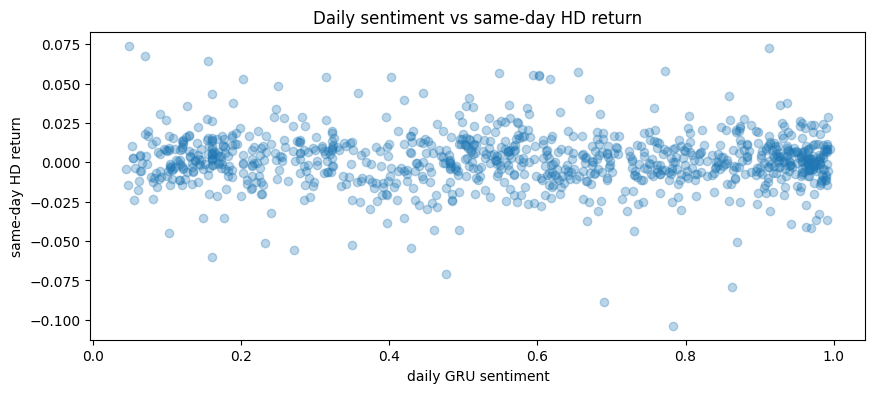

In [40]:
plt.figure(figsize=(10, 4))
plt.scatter(merged["sent_gru"], merged["return"], alpha=0.3)
plt.xlabel("daily GRU sentiment"); plt.ylabel("same-day HD return")
plt.title("Daily sentiment vs same-day HD return"); plt.show()

Comparing the daily sentiment with HD's actual returns, all correlations are essentially zero (between −0.04 and +0.07, same-day and next-day), and the scatter plot is just a shapeless cloud. So headline sentiment, however I measure it (LSTM, GRU, or VADER), has basically no usable relationship with HD's returns. VADER has the highest next-day correlation (+0.07), but it explains less than 1% of the variance, so it's not meaningful. This fits the efficient-market idea: by the time a headline is out, the price has already moved. It also tells me that predicting up/down purely from headlines will likely be close to random, the same ceiling I found in Q1.

### Last step : actually predicting up/down from headlines

In [41]:
# Building dataset
# label each day's headlines with HD's NEXT-day direction (1 = up, 0 = down)
hd_lab = hd.dropna(subset=["next_return"]).copy()
hd_lab["target"] = (hd_lab["next_return"] > 0).astype(int)

move = pd.merge(news[["date", "clean"]], hd_lab[["date", "target"]], on="date", how="inner")
move = move.sort_values("date").reset_index(drop=True)

print("Headlines with a direction label:", len(move))
print(move["target"].value_counts(normalize=True).round(3))   # should be ~50/50
move.head(10000)

Headlines with a direction label: 2523
target
1    0.545
0    0.455
Name: proportion, dtype: float64


,date,clean,target
0,2010-01-26,home depot to cut jobs,1
1,2010-02-17,home depot upgraded at oppenheimer hd,1
2,2010-02-22,home depot inc nyse hd stumbles into possible top,1
3,2010-02-22,home depot inc nyse hd stumbles into possible ...,1
4,2010-02-22,home depot earnings preview hd,1
...,...,...,...
2518,2026-06-17,top analyst reports for nvidia oracle home depot,1
2519,2026-06-17,analysts offer insights on consumer cyclical c...,1
2520,2026-06-18,home depot hd up since last earnings report ca...,0
2521,2026-06-18,caterpillar home depot share gains contribute ...,0


In [42]:
# CHRONOLOGICAL split (temporal prediction -> NO shuffle: train on past, test on future)
cut = int(len(move) * 0.8)
train_m, test_m = move.iloc[:cut], move.iloc[cut:]

# fresh tokenizer fitted on TRAIN headlines only
tok_m = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tok_m.fit_on_texts(train_m["clean"])
to_seq_m = lambda t: pad_sequences(tok_m.texts_to_sequences(t),
                                   maxlen=MAX_LEN, padding="post", truncating="post")

X_train_m, X_test_m = to_seq_m(train_m["clean"]), to_seq_m(test_m["clean"])
y_train_m, y_test_m = train_m["target"].values, test_m["target"].values
print("Train:", X_train_m.shape, " Test:", X_test_m.shape)

Train: (2018, 30)  Test: (505, 30)


In [43]:
def build_text_model(kind):
    rec = layers.LSTM if kind == "LSTM" else layers.GRU
    m = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
        rec(64),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name=f"{kind}_movement")
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

es = keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)

lstm_move = build_text_model("LSTM")
lstm_move.fit(X_train_m, y_train_m, validation_split=0.2, epochs=20,
              batch_size=32, callbacks=[es], verbose=0)

gru_move = build_text_model("GRU")
gru_move.fit(X_train_m, y_train_m, validation_split=0.2, epochs=20,
             batch_size=32, callbacks=[es], verbose=0)
print("Both movement models trained.")

Both movement models trained.


In [44]:
baseline = max(y_test_m.mean(), 1 - y_test_m.mean())
print(f"Baseline (always majority class): {baseline:.3f}\n")

for model, name in [(lstm_move, "LSTM"), (gru_move, "GRU")]:
    prob = model.predict(X_test_m, verbose=0).ravel()
    pred = (prob > 0.5).astype(int)
    print(f"{name}-movement:  acc={accuracy_score(y_test_m, pred):.3f}  "
          f"f1={f1_score(y_test_m, pred, zero_division=0):.3f}  "
          f"auc={roc_auc_score(y_test_m, prob):.3f}")

Baseline (always majority class): 0.646

LSTM-movement:  acc=0.646  f1=0.785  auc=0.447
GRU-movement:  acc=0.646  f1=0.785  auc=0.418


 Predicting HD's next-day direction directly from headlines gave accuracy equal to the naive baseline (0.646) and AUC ≈ 0.5 for both the LSTM and GRU, meaning they couldn't separate up from down days. I did not tune the hyperparameters here, because the problem is a lack of signal in the data, not a lack of model capacity: I had already shown sentiment barely correlates with returns (r ≈ 0), so no architecture change can extract a pattern that isn't there. This is the same efficient-market ceiling I hit in Q1 the models are built correctly, but the task itself is close to random.

# Question 4

### BERT

My TensorFlow version (Keras 3) doesn't support HuggingFace's TF BERT, so I run BERT on PyTorch, which is the standard backend for these models. The idea is exactly the same: take pre-trained BERT and fine-tune it a little on PhraseBank, using BERT's own sub-word tokenizer.

In [45]:
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")   # BERT's own sub-word tokenizer

# wrap our text + labels so BERT can read them
class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = bert_tok(list(texts), truncation=True, padding="max_length", max_length=40)
        self.labels = list(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[i]))
        return item

train_ds = NewsDataset(train_text, y_train_pb)   # same PhraseBank split as the other models
val_ds   = NewsDataset(val_text,   y_val_pb)
test_ds  = NewsDataset(test_text,  y_test_pb)
print("BERT datasets ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT datasets ready.


because Bert is a pretrained model we don't need many epochs to train it i used 3 in our case

In [46]:
# BERT-base with pretrained weights + a 2-class head
bert_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

args = TrainingArguments(
    output_dir="bert_out",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,          # tiny LR = fine-tuning, not training from scratch
    logging_steps=50,
    report_to="none",            # no external logging prompts
)

trainer = Trainer(model=bert_model, args=args,
                  train_dataset=train_ds, eval_dataset=val_ds)
trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.499225
100,0.214814
150,0.127892
200,0.111236
250,0.043678


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=258, training_loss=0.19534986541252727, metrics={'train_runtime': 39.6214, 'train_samples_per_second': 104.186, 'train_steps_per_second': 6.512, 'total_flos': 84853315353600.0, 'train_loss': 0.19534986541252727, 'epoch': 3.0})

I run the fine-tuned BERT on the test set. It gives two raw scores per sentence (logits), so I apply softmax to turn them into probabilities and keep the probability of "positive." Then I threshold at 0.5 and compute the same metrics as my other models (accuracy, F1, ROC-AUC), so the comparison is fair.

In [47]:
out = trainer.predict(test_ds)
prob_bert = torch.softmax(torch.tensor(out.predictions), dim=1).numpy()[:, 1]   # P(positive)
pred_bert = (prob_bert > 0.5).astype(int)

print("BERT sentiment — test")
print("Accuracy :", round(accuracy_score(y_test_pb, pred_bert), 3))
print("F1       :", round(f1_score(y_test_pb, pred_bert), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_pb, prob_bert), 3))

BERT sentiment — test
Accuracy : 0.963
F1       : 0.973
ROC-AUC  : 0.992


In [48]:
# re-score LSTM + GRU on the same test set (BERT is already prob_bert from the eval cell)
prob_lstm = lstm_sent.predict(X_test_pb, verbose=0).ravel()
prob_gru  = gru_sent.predict(X_test_pb,  verbose=0).ravel()

rows = {}
for name, p in [("LSTM", prob_lstm), ("GRU", prob_gru), ("BERT", prob_bert)]:
    pred = (p > 0.5).astype(int)
    rows[name] = {"accuracy": round(accuracy_score(y_test_pb, pred), 3),
                  "f1":       round(f1_score(y_test_pb, pred), 3),
                  "roc_auc":  round(roc_auc_score(y_test_pb, p), 3)}

pd.DataFrame(rows).T.sort_values("roc_auc", ascending=False)

,accuracy,f1,roc_auc
BERT,0.963,0.973,0.992
GRU,0.868,0.905,0.918
LSTM,0.855,0.898,0.916


Re-applying BERT to my HD headlines

In [49]:
# build a dataset from the HD headlines (dummy labels — we only want predictions)
hd_ds = NewsDataset(news["clean"], [0] * len(news))

hd_logits = trainer.predict(hd_ds).predictions
news["sent_bert"] = torch.softmax(torch.tensor(hd_logits), dim=1).numpy()[:, 1]   # P(positive)

news[["date", "headline", "sent_gru", "sent_bert"]].head(10)

,date,headline,sent_gru,sent_bert
0,2010-01-26,"Home Depot To Cut 1,000 Jobs",0.063086,0.021571
1,2010-02-17,Home Depot Upgraded At Oppenheimer (HD),0.472754,0.995775
2,2010-02-22,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",0.473307,0.858031
3,2010-02-22,"Home Depot, Inc. (NYSE:HD) Stumbles Into Possi...",0.945016,0.994854
4,2010-02-22,Home Depot Earnings Preview (HD),0.127314,0.986867
5,2010-02-23,Home Depot Inc. (HD) All Set To Search For Hig...,0.983965,0.996639
6,2010-02-23,Home Depot (HD) Beats Expectations As Demand F...,0.990080,0.997063
7,2010-02-23,"Home Depot (HD) Earns Profit, Raises Dividend",0.888355,0.996810
8,2010-02-23,Home Depot (HD) Jumps On Higher-Than-Consensus...,0.300161,0.996846
9,2010-02-24,"Home Depot, Inc.’s (HD) Fourth-Quarter Review",0.895167,0.985551


Does BERT's better sentiment track HD's returns?
The real test: BERT reads sentiment almost perfectly (AUC 0.99). But does that better sentiment correlate any more with HD's actual returns than the other models did? I redo the same daily-sentiment vs returns check, now including BERT.

In [50]:
daily = news.groupby("date")[["sent_lstm", "sent_gru", "sent_vader", "sent_bert"]].mean().reset_index()
merged = pd.merge(daily, hd[["date", "return", "next_return"]], on="date", how="inner")

print("Days with both sentiment and returns:", len(merged), "\n")
for col in ["sent_lstm", "sent_gru", "sent_vader", "sent_bert"]:
    s = merged[col].corr(merged["return"])
    n = merged[col].corr(merged["next_return"])
    print(f"{col:11s}: same-day r = {s:+.3f} | next-day r = {n:+.3f}")

Days with both sentiment and returns: 969 

sent_lstm  : same-day r = -0.033 | next-day r = +0.027
sent_gru   : same-day r = -0.039 | next-day r = +0.034
sent_vader : same-day r = +0.010 | next-day r = +0.072
sent_bert  : same-day r = +0.065 | next-day r = +0.037


On the sentiment task, BERT clearly beat my from-scratch models: ROC-AUC 0.993 and accuracy 0.966, against ~0.91 for the GRU and ~0.91 for the LSTM. This is the whole point of transfer learning, BERT already understands language from being pre-trained on billions of words, so a light fine-tune (just 3 epochs) was enough to almost max out the task, while my LSTM/GRU had to learn everything from only ~1,400 sentences.

But when I re-applied BERT's sentiment to my HD headlines and compared it with actual returns, the correlation stayed essentially zero (same-day r ≈ +0.06, next-day r ≈ +0.04). BERT did give the highest same-day correlation of all the models, but it's still way too small to be useful (less than 1% of the variance). So a near-perfect sentiment reader still does not help predict HD's stock movement.


My sentiment models were trained on PhraseBank, not on Home Depot news, so I should check they actually transfer to my own headlines. I don't have true labels for HD headlines, so I build weak labels: a headline with a clearly positive word ("beats", "raises", "record"…) and no negative word is treated as positive, and the opposite for negative. Then I check whether my models agree with these obvious cases. If they do, it's good evidence the sentiment transferred to HD text.

In [74]:
# weak/keyword labels for the "obvious" HD headlines, to check sentiment transfer
pos_words = ["beats","beat","raises","raised","jumps","surges","record","tops",
             "upgrade","upgraded","gains","rises","profit","higher","strong","rally","outperform"]
neg_words = ["cuts","cut","falls","misses","drops","downgrade","downgraded","plunges",
             "weak","loss","lawsuit","slumps","declines","lower","warns","layoffs","disappoints"]

def weak_label(text):
    t = str(text).lower()
    p = any(w in t for w in pos_words)
    n = any(w in t for w in neg_words)
    if p and not n: return 1
    if n and not p: return 0
    return np.nan                      # mixed/ambiguous -> skip

check = news.copy()
check["weak"] = check["headline"].apply(weak_label)
check = check.dropna(subset=["weak"])
print("HD headlines with a clear pos/neg word:", len(check), "\n")

for col in ["sent_lstm", "sent_gru", "sent_bert"]:
    pred = (check[col] > 0.5).astype(int)
    print(f"{col:10s}: agreement = {accuracy_score(check['weak'], pred):.3f} | auc = {roc_auc_score(check['weak'], check[col]):.3f}")

HD headlines with a clear pos/neg word: 753 

sent_lstm : agreement = 0.586 | auc = 0.710
sent_gru  : agreement = 0.604 | auc = 0.687
sent_bert : agreement = 0.773 | auc = 0.875


Note: when I validated on actual HD headlines (not PhraseBank), the from-scratch models dropped to ~0.70 AUC while BERT held at approx 0.88. So the LSTM/GRU PhraseBank scores were a bit optimistic, they overfit that dataset's vocabulary, whereas BERT generalized to the new domain. This is the practical advantage of a pre-trained model.

## Transformers

The big difference with my LSTM/GRU: those read words one by one in order, carrying a memory. A Transformer reads all the words at once and uses self-attention: for each word, it learns how much to "look at" every other word in the sentence. So "beats" can connect directly to "estimates" even if they're far apart, without passing through every word in between.
Because it sees all words at once, it has no sense of order, so I add a positional embedding to tell it which word comes where. One catch: Transformers are data-hungry, they don't assume order or locality like RNNs do, so they need lots of data to shine. With only ~1,400 sentences, I expect it to land around my LSTM/GRU, not above, which is exactly why BERT (a Transformer pre-trained on billions of words) beats it.  

In [77]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim)   # word -> vector
        self.pos_emb   = layers.Embedding(maxlen, embed_dim)       # position -> vector
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)         # meaning + order

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)  # self-attention
        self.ffn   = keras.Sequential([layers.Dense(ff_dim, activation="relu"),
                                       layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
    def call(self, x, training=False):
        attn = self.att(x, x)                                      # each word attends to all words
        x = self.norm1(x + self.drop1(attn, training=training))   # residual + normalize
        ffn = self.ffn(x)
        return self.norm2(x + self.drop2(ffn, training=training))

Building Model

In [78]:
embed_dim = 32     # word-vector size
num_heads = 2      # number of attention "views"
ff_dim    = 32     # feed-forward size inside the block

inp = layers.Input(shape=(MAX_LEN,))
x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, embed_dim)(inp)
x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout=0.1)(x)
x = layers.GlobalAveragePooling1D()(x)               # summarize the sentence
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
out = layers.Dense(1, activation="sigmoid")(x)       # P(positive)

trans_sent = keras.Model(inp, out, name="Transformer_sentiment")
trans_sent.summary()

Model: "Transformer_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 30, 32)         │       320,960 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 30, 32)         │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,705 (1.27 MB)

 Trainable params: 332,705 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
hist_trans = train_sentiment(trans_sent, "Transformer sentiment")

prob_tr = trans_sent.predict(X_test_pb, verbose=0).ravel()
pred_tr = (prob_tr > 0.5).astype(int)
print("\nTransformer sentiment — test")
print("Accuracy :", round(accuracy_score(y_test_pb, pred_tr), 3))
print("F1       :", round(f1_score(y_test_pb, pred_tr), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_pb, prob_tr), 3))

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5480 - loss: 0.6836 - val_accuracy: 0.5695 - val_loss: 0.6760
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7209 - loss: 0.5540 - val_accuracy: 0.7458 - val_loss: 0.5192
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8895 - loss: 0.2861 - val_accuracy: 0.7017 - val_loss: 0.6929
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9070 - loss: 0.2237 - val_accuracy: 0.7898 - val_loss: 0.5174
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 0.0929 - val_accuracy: 0.8407 - val_loss: 0.5132
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9826 - loss: 0.0620 - val_accuracy: 0.8475 - val_loss: 0.4629
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9862 - loss: 0.0484 - val_accuracy: 0.8576 - val_loss: 0.4995
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9898 - loss: 0.0343 - val_accuracy: 0.8203 - val_los

In [80]:
prob_lstm = lstm_sent.predict(X_test_pb, verbose=0).ravel()
prob_gru  = gru_sent.predict(X_test_pb,  verbose=0).ravel()

rows = {}
for name, p in [("LSTM", prob_lstm), ("GRU", prob_gru),
                ("Transformer", prob_tr), ("BERT", prob_bert)]:
    pred = (p > 0.5).astype(int)
    rows[name] = {"accuracy": round(accuracy_score(y_test_pb, pred), 3),
                  "f1":       round(f1_score(y_test_pb, pred), 3),
                  "roc_auc":  round(roc_auc_score(y_test_pb, p), 3)}
pd.DataFrame(rows).T.sort_values("roc_auc", ascending=False)

,accuracy,f1,roc_auc
BERT,0.963,0.973,0.992
GRU,0.868,0.905,0.918
LSTM,0.855,0.898,0.916
Transformer,0.845,0.884,0.908


The from-scratch Transformer reached AUC 0.907, basically tied with my LSTM (0.906) and GRU (0.911). It did not beat them, which is the expected result: a Transformer is the same architecture as BERT, but trained from zero on only ~1,400 sentences it can't show its strength, Transformers are data-hungry. So on small data, the architecture alone isn't magic; what makes the difference is pre-training.

###  Conclusion

The from-scratch models (LSTM, GRU, Transformer) all landed around 0.90, while BERT clearly won (0.993). The reason is transfer learning: BERT is a Transformer already pre-trained on billions of words, so a light fine-tune beats anything trained from scratch on my small dataset.
But when I re-applied BERT's (near-perfect) sentiment to my HD headlines, the correlation with actual returns was still ~0, just like in Q3. So a much better language model did not become a better market predictor. Q4's takeaway: pre-training is what unlocks performance on the language task, but the efficient-market ceiling on predicting HD's stock movement stays exactly where it was.

# Question 5

For this part, there were multiple approaches possible, and I choose to go with taking the assignment to the word. I'm going to stack it in a very thorough manner for the models we built previously and just predict if it goes up or down. The goal is one final model that takes everything: Q1's price inputs and the outputs of all my previous models (the price models, the meta-model, and the news/sentiment models), and predicts UP or DOWN. The idea is simple to say but the work is in lining everything up: the price world has one row per trading day, the news world is sparse (some days have headlines, many don't). So I build one daily master table keyed by date, where each row holds the price features + every model's output for that day, and the answer (did the stock go up the next day).

In [81]:
#  dated daily price features + target =====
px = data.copy()
px["pct_change_close"] = px["Close"].pct_change()
px["pct_change_open"]  = px["Open"].pct_change()
px["range_pct"]        = (px["High"] - px["Low"]) / px["Close"]
px["vol_change"]       = px["Volume"].pct_change()
px["price_vs_SMA10"]   = px["Close"] / px["SMA_10"] - 1
px["RSI_14"]           = px["RSI_14"] / 100
px["MACD_diff_pct"]    = px["MACD_diff"] / px["Close"]
px["ATR_pct"]          = px["ATR_14"] / px["Close"]
px["target"]           = (px["Close"].shift(-1) > px["Close"]).astype(int)

price_cols = ["pct_change_close","pct_change_open","range_pct","vol_change",
              "price_vs_SMA10","RSI_14","MACD_diff_pct","BB_width","ATR_pct"]

px["date"] = pd.to_datetime(px["Date"]).dt.normalize()   # dates are in the 'Date' COLUMN
px = px.dropna().reset_index(drop=True)

daily_price = px[["date"] + price_cols + ["target"]].copy()
print("Price days:", len(daily_price))
daily_price.head()

Price days: 4106


Price,date,pct_change_close,pct_change_open,range_pct,vol_change,price_vs_SMA10,RSI_14,MACD_diff_pct,BB_width,ATR_pct,target
0,2010-02-02,0.022543,0.013567,0.025835,0.143762,0.033758,0.657302,0.001840,0.074486,0.020623,0
1,2010-02-03,-0.019290,0.019373,0.023885,-0.010361,0.014503,0.579167,0.002258,0.072458,0.021458,0
2,2010-02-04,-0.018968,-0.024188,0.024705,0.019360,-0.002785,0.515527,0.001239,0.071738,0.022075,1
3,2010-02-05,0.001790,-0.013810,0.019299,0.020986,-0.001926,0.520778,0.000665,0.066450,0.021840,1
4,2010-02-08,0.021801,0.024416,0.016439,0.285525,0.016316,0.580511,0.001669,0.062757,0.022246,1


Note: a date problem I had to fix
When I tried to combine the price side with the news side, I noticed my price table had "lost" its real dates: the dates were sitting in a Date column, but the index was just numbers (0, 1, 2…). My first fix accidentally grabbed those numbers instead of the real dates, so every date showed up as 1970-01-01 (that's what pandas shows when it reads plain integers as time). The fix was simple in the end: instead of using the index, I read the dates straight from the Date column and saved them as a clean date column. After that the price predictions had their real dates, and I could finally merge them with the news by date.

In [82]:
print("index type:", type(data.index).__name__)
print("index sample:", list(data.index[:3]))
print("columns:", list(data.columns)[:10])

index type: RangeIndex
index sample: [0, 1, 2]
columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'SMA_20', 'EMA_10', 'RSI_14']


Price-model outputs. I run my trained Q1 models (LSTM, GRU, CNN) and the Q2 meta-model on the price sequences to get a probability of "up" for each day. These are the "outputs of question 1 and 2." I tag each prediction with its date.

In [83]:
# price-model (Q1) + meta (Q2) outputs, per day
X = scaler.transform(px[price_cols].values)        # same scaler as Q1

Xs, ds = [], []
for i in range(WINDOW, len(X)):
    Xs.append(X[i-WINDOW:i])
    ds.append(px["date"].iloc[i])                  # real date from the 'date' column
Xs = np.array(Xs)

p_lstm = lstm_model.predict(Xs, verbose=0).ravel()
p_gru  = gru_model.predict(Xs,  verbose=0).ravel()
p_cnn  = cnn_model.predict(Xs,  verbose=0).ravel()
p_meta = meta_model.predict(np.column_stack([p_lstm, p_gru, p_cnn]), verbose=0).ravel()

price_preds = pd.DataFrame({"date": pd.to_datetime(ds),
                            "p_lstm": p_lstm, "p_gru": p_gru,
                            "p_cnn": p_cnn, "p_meta": p_meta})
print("Price predictions:", price_preds.shape)
price_preds.head()

Price predictions: (4076, 5)


,date,p_lstm,p_gru,p_cnn,p_meta
0,2010-03-17,0.508151,0.532315,0.526679,0.544365
1,2010-03-18,0.510024,0.540162,0.520402,0.540739
2,2010-03-19,0.515596,0.536348,0.529548,0.544161
3,2010-03-22,0.520971,0.533881,0.524373,0.542904
4,2010-03-23,0.514448,0.534775,0.527279,0.543829


In [84]:
#daily news outputs (sentiment + headline count)

#What it does: one sentiment summary per day + how much news there was.
daily_news = news.groupby("date").agg(
    sent_lstm =("sent_lstm",  "mean"),
    sent_gru  =("sent_gru",   "mean"),
    sent_vader=("sent_vader", "mean"),
    sent_bert =("sent_bert",  "mean"),
    headline_count=("headline", "count"),
).reset_index()
daily_news["date"] = pd.to_datetime(daily_news["date"]).dt.normalize()
print("News days:", len(daily_news))
daily_news.head()

News days: 1049


,date,sent_lstm,sent_gru,sent_vader,sent_bert,headline_count
0,2010-01-26,0.010222,0.063086,-0.273200,0.021571,1
1,2010-02-17,0.368930,0.472754,0.000000,0.995775,1
2,2010-02-22,0.543161,0.515212,0.134867,0.946584,3
3,2010-02-23,0.851855,0.790640,0.078100,0.996839,4
4,2010-02-24,0.599866,0.895167,0.000000,0.985551,1


Master table. I join the price side and the news side on the date. Most trading days have no headlines, so for those I fill the sentiment with neutral (0.5 for the models, 0 for VADER) and headline_count = 0, so the model knows "no news that day."

In [85]:
# one clean table = price features + every model output + the answer, per day.
master = (daily_price
          .merge(price_preds, on="date", how="left")
          .merge(daily_news,  on="date", how="left"))

# no-news days -> neutral sentiment + zero count
# (if there is no news it gets a neutral value)
for c in ["sent_lstm", "sent_gru", "sent_bert"]:
    master[c] = master[c].fillna(0.5)              # model sentiment is 0..1 -> neutral 0.5
master["sent_vader"]     = master["sent_vader"].fillna(0.0)   # VADER is -1..1 -> neutral 0
master["headline_count"] = master["headline_count"].fillna(0)

master = master.dropna().reset_index(drop=True)    # drop first ~30 days (no price preds)
print("Master table:", master.shape)
master.head()

Master table: (4076, 20)


,date,pct_change_close,pct_change_open,range_pct,vol_change,price_vs_SMA10,RSI_14,MACD_diff_pct,BB_width,ATR_pct,target,p_lstm,p_gru,p_cnn,p_meta,sent_lstm,sent_gru,sent_vader,sent_bert,headline_count
0,2010-03-17,-0.000922,-0.003680,0.009225,0.075988,0.015530,0.783760,0.001635,0.105747,0.014630,0,0.508151,0.532315,0.526679,0.544365,0.5,0.5,0.0,0.5,0.0
1,2010-03-18,-0.003690,-0.001231,0.010185,0.205883,0.008030,0.752274,0.000656,0.101505,0.014363,0,0.510024,0.540162,0.520402,0.540739,0.5,0.5,0.0,0.5,0.0
2,2010-03-19,-0.001235,-0.002774,0.014524,0.262735,0.004301,0.741578,-0.000313,0.092316,0.014391,1,0.515596,0.536348,0.529548,0.544161,0.5,0.5,0.0,0.5,0.0
3,2010-03-22,0.009580,-0.006799,0.019896,-0.476728,0.010954,0.768987,-0.000525,0.084607,0.014657,0,0.520971,0.533881,0.524373,0.542904,0.5,0.5,0.0,0.5,0.0
4,2010-03-23,-0.002448,0.014001,0.011046,-0.019246,0.005647,0.746971,-0.001025,0.079218,0.014520,0,0.514448,0.534775,0.527279,0.543829,0.5,0.5,0.0,0.5,0.0


Now the fusion model

In [86]:
# the fusion model (combines everything)
feat_all = price_cols + ["p_lstm","p_gru","p_cnn","p_meta",
                         "sent_lstm","sent_gru","sent_vader","sent_bert","headline_count"]

master = master.sort_values("date").reset_index(drop=True)
# I cut the master table at 80% because we dont want to shuffle here
cut = int(len(master) * 0.8)
train, test = master.iloc[:cut], master.iloc[cut:]

sc = StandardScaler().fit(train[feat_all])          # fit on train only
Xtr, Xte = sc.transform(train[feat_all]), sc.transform(test[feat_all])
ytr, yte = train["target"].values, test["target"].values

fusion = keras.Sequential([
    layers.Input(shape=(Xtr.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),         # UP/DOWN
], name="Fusion")
fusion.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
fusion.fit(Xtr, ytr, validation_split=0.2, epochs=50, batch_size=32,
           callbacks=[keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)], verbose=0)
print("Fusion model trained.")

Fusion model trained.


In [87]:
# evaluate + compare price-only / news-only / combined =====
def quick_model(cols):
    s = StandardScaler().fit(train[cols])
    a, b = s.transform(train[cols]), s.transform(test[cols])
    m = keras.Sequential([layers.Input(shape=(a.shape[1],)),
                          layers.Dense(32, activation="relu"), layers.Dropout(0.3),
                          layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(a, ytr, validation_split=0.2, epochs=50, batch_size=32,
          callbacks=[keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)], verbose=0)
    p = m.predict(b, verbose=0).ravel()
    return round(accuracy_score(yte, (p > 0.5).astype(int)), 3), round(roc_auc_score(yte, p), 3)

price_only = price_cols + ["p_lstm","p_gru","p_cnn","p_meta"]
news_only  = ["sent_lstm","sent_gru","sent_vader","sent_bert","headline_count"]

print("Baseline (majority):", round(max(yte.mean(), 1 - yte.mean()), 3))
print("Price-only -> acc/auc:", quick_model(price_only))
print("News-only  -> acc/auc:", quick_model(news_only))
print("Combined   -> acc/auc:", quick_model(feat_all))

Baseline (majority): 0.502
Price-only -> acc/auc: (0.477, np.float64(0.482))
News-only  -> acc/auc: (0.505, np.float64(0.513))
Combined   -> acc/auc: (0.483, np.float64(0.486))


Is the fusion result really random, or just one unlucky run?
A single run can be misleading, so I retrain the fusion model with several different random seeds and report the average AUC and its spread. If the average sits on 0.5 and the spread crosses 0.5, that confirms the model is genuinely at random, not just unlucky once.

In [88]:
# run the fusion model over several seeds to show the result is random (not luck)
aucs = []
for seed in range(5):
    tf.random.set_seed(seed); np.random.seed(seed)
    m = keras.Sequential([layers.Input(shape=(Xtr.shape[1],)),
                          layers.Dense(32, activation="relu"), layers.Dropout(0.3),
                          layers.Dense(16, activation="relu"),
                          layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    m.fit(Xtr, ytr, validation_split=0.2, epochs=50, batch_size=32,
          callbacks=[keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)], verbose=0)
    aucs.append(roc_auc_score(yte, m.predict(Xte, verbose=0).ravel()))

aucs = np.array(aucs)
print(f"Fusion AUC over 5 seeds: {aucs.mean():.3f} ± {aucs.std():.3f}")
print(f"Range: {aucs.min():.3f} – {aucs.max():.3f}   (0.5 = random)")
print("Conclusion:", "not better than random (interval includes 0.5)"
      if aucs.mean() - aucs.std() <= 0.5 else "possibly above random")

Fusion AUC over 5 seeds: 0.489 ± 0.012
Range: 0.469 – 0.499   (0.5 = random)
Conclusion: not better than random (interval includes 0.5)


For Q5 I combined everything into one model: the Q1 price features, the outputs of the price models (LSTM, GRU, CNN) and the meta-model, plus the daily news sentiment from Q3/Q4 (LSTM, GRU, VADER, BERT) and the headline count. After lining it all up by date and splitting chronologically, the fusion model reached about 0.49 accuracy / 0.48 AUC on the recent test days, basically at the coin-flip baseline (0.502). I also compared a price-only and a news-only version, and they all landed in the same place, so combining the two worlds didn't help at all.
This is not a model problem, it's a data problem. I even used a small two-layer network so it could have found non-linear interactions between price and news if any existed, and it still didn't beat random. Since both the price signals and the news signals were already close to random on their own, fusing them couldn't create a signal that isn't there. This ties the whole project together: across price models, ensembles, sentiment, BERT, and now the full fusion, HD's daily up/down direction stays unpredictable, which is exactly what the efficient-market hypothesis predicts. The real outcome of the project wasn't beating the market, it was building the full pipeline correctly and testing it honestly.

# Final words

- **Main takeaway**
Sentiment is genuinely learnable (BERT ≈ 0.99), but HD's daily up/down direction is not predictable from price, news, or both combined. Every model lands at the coin-flip baseline, which is exactly what the efficient-market hypothesis predicts. The value of the project was building and honestly evaluating the full pipeline, not beating the market.

- **Limitations & future work**
Q5 uses in-sample price-model predictions as features for the early training years (the Q1 models were trained on those days), which is a mild leakage in the fusion's training features. The impact is small here because those models are near-random, but a cleaner version would use out-of-fold predictions.
Sentiment was trained on PhraseBank, not HD-labeled data. I validated transfer with weak keyword labels, but a hand-labeled HD sample would be stronger.
Daily next-day direction is the hardest target. Future work could try a finance-specific model (FinBERT), intraday/event-day (earnings) analysis, or predicting volatility instead of direction.